# AI Ethics & Policy Q&A Assistant — RAG Pipeline

### Dataset

Three authoritative AI policy documents are used as the knowledge base:

| Document | Source | Focus |
|----------|--------|-------|
| EU AI Act | European Parliament, 2024 | Risk classification, obligations, prohibited practices |
| OECD AI Principles | OECD, 2019 (rev. 2024) | Trustworthy AI values and governance recommendations |
| UNESCO AI Ethics | UNESCO, 2021 | Human rights, sustainability, and ethical AI development |

### Pipeline

1. **Data Preparation** 
2. **Embedding** 
3. **Vector Storage** 
4. **Retrieval** 
5. **Prompt Construction** 
6. **Generation** 
7. **Response** 

## 0. Setup

In [2]:
import time
import os
import pandas as pd
from tqdm import tqdm
import chromadb
from sentence_transformers import SentenceTransformer
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import gradio as gr

## 1. Data Preparation

Three AI policy PDFs are loaded and split into overlapping chunks for embedding.

In [3]:
pdf_files = [
    "data/eu_ai_act.pdf",
    "data/oecd_ai_principles.pdf",
    "data/unesco_ai_ethics.pdf"
]

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_chunks = []

for pdf_path in pdf_files:
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    chunks = splitter.split_documents(docs)
    all_chunks.extend(chunks)
    print(f"  {os.path.basename(pdf_path)}: {len(docs)} pages, {len(chunks)} chunks")

text_lines = [c.page_content for c in all_chunks]
print(f"\nTotal chunks: {len(text_lines)}")

  eu_ai_act.pdf: 144 pages, 804 chunks
  oecd_ai_principles.pdf: 6 pages, 22 chunks
  unesco_ai_ethics.pdf: 21 pages, 129 chunks

Total chunks: 955


In [4]:
print("Sample chunk (index 10):")
print(text_lines[10])

Sample chunk (index 10):
move ment of goods and ser vices. Those r ules should be clear and robust in protecting fundamental r ights, 
suppor tive of new innovative solutions, enabling a European ecosyste m of public and pr ivate actor s creating AI 
syste ms in line with Union values and unlocking the potential of the digital transf or mation across all regions of the 
Uni on. By la ying down those r ules as well as measures in suppor t of inno vation with a par ticular f ocus on small and 
medium ent er pr ises (SMEs), including star tups, this Regulation suppor ts the objective of promoting the European 
human-centr ic approach to AI and being a g lobal leader in the development of secure, tr ustwor thy and ethical AI as 
stat ed by the European Council (
5
), and it ensures the prot ection of ethical pr inciples, as specific ally request ed by the 
European Pa rliament (
6
).
EN
OJ L, 12.7.2024
2/144 ELI: http://data.europa.eu/eli/reg/2024/1689/oj
(
5


## 2. Embedding Generation

Two embedding models are compared:
- **`all-MiniLM-L6-v2`**: fast and lightweight (384 dimensions)
- **`all-mpnet-base-v2`**: higher quality, larger (768 dimensions)

In [5]:
emb_model_1 = SentenceTransformer("all-MiniLM-L6-v2")
emb_model_2 = SentenceTransformer("all-mpnet-base-v2")

def embed(model, text):
    return model.encode([text], normalize_embeddings=True).tolist()[0]

test_sentence = "What are the requirements for high-risk AI systems?"
e1 = embed(emb_model_1, test_sentence)
e2 = embed(emb_model_2, test_sentence)

print(f"MiniLM embedding dimension: {len(e1)}")
print(f"MPNet embedding dimension: {len(e2)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MiniLM embedding dimension: 384
MPNet embedding dimension: 768


## 3. Vector Database Setup with ChromaDB

Two separate collections are created in a local persistent ChromaDB instance, one per embedding model, so we can compare retrieval quality later.

In [6]:
client = chromadb.PersistentClient(path="./rag_db")

def fresh_collection(name):
    try:
        client.delete_collection(name)
    except Exception:
        pass
    return client.create_collection(name)

col_minilm = fresh_collection("col_minilm")
col_mpnet  = fresh_collection("col_mpnet")

embs1, embs2, ids = [], [], []
for i, line in enumerate(tqdm(text_lines, desc="Building embeddings")):
    embs1.append(embed(emb_model_1, line))
    embs2.append(embed(emb_model_2, line))
    ids.append(str(i))

col_minilm.add(documents=text_lines, embeddings=embs1, ids=ids)
col_mpnet.add(documents=text_lines,  embeddings=embs2, ids=ids)

print(f"Collections ready: {col_minilm.count()} documents each")

Building embeddings: 100%|██████████| 955/955 [01:14<00:00, 12.88it/s]


Collections ready: 955 documents each


## 4. Integration with Hugging Face LLMs

Two instruction-tuned models from Hugging Face are loaded:
- **`google/flan-t5-base`**: ~250 MB, fast inference
- **`google/flan-t5-large`**: ~800 MB, better answer quality

In [7]:
def load_flan_t5(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    def generate(prompt, max_new_tokens=256):
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
        return [{"generated_text": tokenizer.decode(outputs[0], skip_special_tokens=True)}]
    return generate

print("Loading flan-t5-base:")
llm_base  = load_flan_t5("google/flan-t5-base")
print("Loading flan-t5-large:")
llm_large = load_flan_t5("google/flan-t5-large")

LLMS = {"flan-t5-base": llm_base, "flan-t5-large": llm_large}

Loading flan-t5-base:


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading flan-t5-large:


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## 5. Prompt Engineering

Three prompt templates are tested to assess how framing affects answer quality.

In [8]:
PROMPT_BASIC = (
    "Answer the question using only the context below.\n\n"
    "Context: {context}\n\nQuestion: {question}\nAnswer:"
)

PROMPT_XML = (
    "Use the information enclosed in <context> tags to provide an answer to the "
    "question enclosed in <question> tags.\n"
    "<context>\n{context}\n</context>\n"
    "<question>\n{question}\n</question>"
)

PROMPT_EXPERT = (
    "You are an AI policy expert. Using only the provided context, give a precise "
    "and factual answer.\n\n"
    "Context:\n{context}\n\n"
    "Question: {question}\n\n"
    "Answer (based strictly on the context above):"
)

PROMPTS = {"Basic": PROMPT_BASIC, "XML Tags": PROMPT_XML, "Expert": PROMPT_EXPERT}

## 6. End-to-End RAG Pipeline

The full pipeline: **query → embedding → ChromaDB retrieval → prompt construction → LLM generation**

In [9]:
def retrieve(question, collection, emb_model, k=3):
    q_emb = embed(emb_model, question)
    res = collection.query(query_embeddings=[q_emb], n_results=k)
    return res["documents"][0]

def rag(question, collection, emb_model, llm, prompt_template, k=3):
    t0 = time.time()
    docs = retrieve(question, collection, emb_model, k)
    t_ret = time.time() - t0

    context = "\n\n".join(docs)
    prompt = prompt_template.format(context=context, question=question)

    t1 = time.time()
    answer = llm(prompt, max_new_tokens=256)[0]["generated_text"]
    t_gen = time.time() - t1

    return {"answer": answer, "t_retrieve": round(t_ret, 3), "t_generate": round(t_gen, 3)}

In [10]:
q = "What obligations does the EU AI Act impose on high-risk AI systems?"
result = rag(q, col_mpnet, emb_model_2, llm_large, PROMPT_XML)

print(f"Question: {q}")
print(f"Answer: {result['answer']}")
print(f"\nRetrieval: {result['t_retrieve']}s | Generation: {result['t_generate']}s")

Question: What obligations does the EU AI Act impose on high-risk AI systems?
Answer: What are the r ights and guarantees a warded to them b y such Uni on law?

Retrieval: 0.528s | Generation: 113.579s


The answer returned here is not valid — the model copied a sentence from the context instead of answering the question. This is likely due to flan-t5's 512-token input limit: the three retrieved chunks already fill most of the window, leaving little room for the question itself. Using a model with a longer context window (e.g. Mistral-7B) would help.

## 7. Evaluation and Optimization

### 7.1 Retrieval Latency — Embedding Model Comparison

In [11]:
eval_questions = [
    "What are the main OECD principles for responsible AI?",
    "What AI applications are prohibited under the EU AI Act?",
    "How does UNESCO approach AI ethics and human rights?",
    "What transparency requirements apply to AI systems?",
    "How should AI developers handle data governance?"
]

retrieval_stats = []
for q in eval_questions:
    t0 = time.time(); retrieve(q, col_minilm, emb_model_1); t1 = round(time.time() - t0, 4)
    t0 = time.time(); retrieve(q, col_mpnet,  emb_model_2); t2 = round(time.time() - t0, 4)
    retrieval_stats.append({"question": q, "MiniLM (s)": t1, "MPNet (s)": t2})

df_ret = pd.DataFrame(retrieval_stats)
print(df_ret.to_string(index=False))
print(f"\nMean — MiniLM: {df_ret['MiniLM (s)'].mean():.4f}s | MPNet: {df_ret['MPNet (s)'].mean():.4f}s")

                                                question  MiniLM (s)  MPNet (s)
   What are the main OECD principles for responsible AI?      1.6700     0.2014
What AI applications are prohibited under the EU AI Act?      0.0277     0.0618
    How does UNESCO approach AI ethics and human rights?      0.0810     0.0738
     What transparency requirements apply to AI systems?      0.0641     0.0766
        How should AI developers handle data governance?      0.0099     0.0265

Mean — MiniLM: 0.3705s | MPNet: 0.0880s


### 7.2 Qualitative Retrieval Comparison

Comparing the top retrieved document for the same query across both embedding models.

In [12]:
q = "What are the prohibited AI practices in the EU AI Act?"

docs_minilm = retrieve(q, col_minilm, emb_model_1)
docs_mpnet  = retrieve(q, col_mpnet,  emb_model_2)

print("MiniLM top result")
print(docs_minilm[0][:400])
print("\nMPNet top result")
print(docs_mpnet[0][:400])

MiniLM top result
1.2. Respect for the rule of law, human rights and democratic values,  including fairness 
and privacy 
a) AI actors should respect the rule of law, human rights, democratic and human-centred 
values throughout the AI system lifecycle. These include non-discrimination and equality, 
freedom, dignity, autonomy of individuals, privacy and data protection, diversity, fairness, 
social justice, and in

MPNet top result
r ights and guarantees a warded to them b y such Uni on law , including the r ights related to solely automat ed individual 
decision-making, including prof iling. Har monised r ules f or the placing on the marke t, the putting into ser vice and 
the use of AI systems established under this Regulation should f acilitate the effe ctive imp lementation and enable the 
ex ercise of the data subjects’


### 7.3 Generation Comparison — LLMs × Prompt Templates

In [13]:
gen_questions = [
    "What are the OECD principles for trustworthy AI?",
    "Which AI systems are considered high-risk under the EU AI Act?"
]

gen_results = []
for q in gen_questions:
    for llm_name, llm in LLMS.items():
        for pt_name, pt in PROMPTS.items():
            r = rag(q, col_mpnet, emb_model_2, llm, pt)
            gen_results.append({
                "question": q[:40] + "...",
                "llm": llm_name,
                "prompt": pt_name,
                "answer_preview": r["answer"][:80] + "...",
                "t_generate (s)": r["t_generate"]
            })

df_gen = pd.DataFrame(gen_results)
print(df_gen.to_string(index=False))

                                   question           llm   prompt                                                                      answer_preview  t_generate (s)
What are the OECD principles for trustwo...  flan-t5-base    Basic b) Governments should work together in the OECD and other global and regional fo...           5.474
What are the OECD principles for trustwo...  flan-t5-base XML Tags                                                                      AI systems....           2.385
What are the OECD principles for trustwo...  flan-t5-base   Expert                                                                    human dignity...           1.426
What are the OECD principles for trustwo... flan-t5-large    Basic c) Governments should promote the development of multi-stakeholder, consensus-dr...          90.751
What are the OECD principles for trustwo... flan-t5-large XML Tags                                                                       AI systems...          16.49

In [14]:
print("Average generation time by LLM")
print(df_gen.groupby("llm")["t_generate (s)"].mean().round(3))

print("\nAverage generation time by prompt template")
print(df_gen.groupby("prompt")["t_generate (s)"].mean().round(3))

Average generation time by LLM
llm
flan-t5-base       2.526
flan-t5-large    153.487
Name: t_generate (s), dtype: float64

Average generation time by prompt template
prompt
Basic        57.157
Expert      102.817
XML Tags     74.045
Name: t_generate (s), dtype: float64


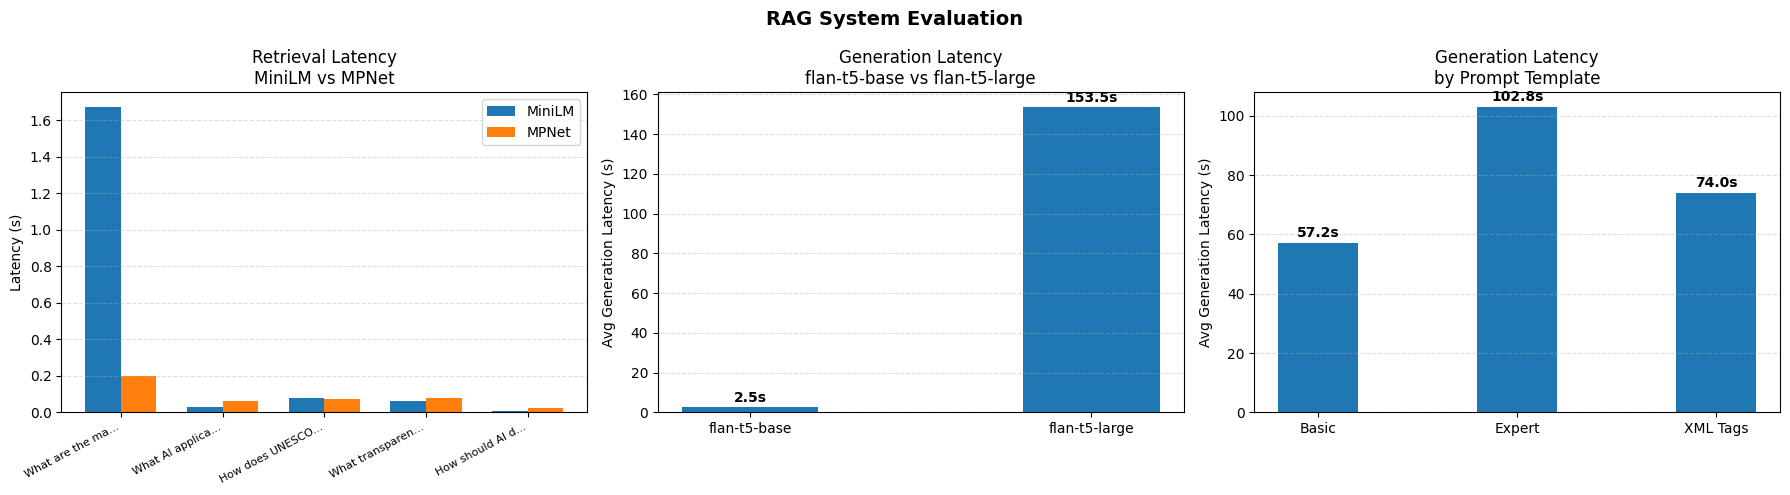

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RAG System Evaluation", fontsize=14, fontweight="bold")

ax1 = axes[0]
x = np.arange(len(df_ret))
w = 0.35
ax1.bar(x - w/2, df_ret["MiniLM (s)"], w, label="MiniLM")
ax1.bar(x + w/2, df_ret["MPNet (s)"], w, label="MPNet")
ax1.set_xticks(x)
ax1.set_xticklabels([q[:15] + "..." for q in df_ret["question"]], rotation=28, ha="right", fontsize=8)
ax1.set_ylabel("Latency (s)")
ax1.set_title("Retrieval Latency\nMiniLM vs MPNet")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax2 = axes[1]
llm_avg = df_gen.groupby("llm")["t_generate (s)"].mean()
bars = ax2.bar(llm_avg.index, llm_avg.values, width=0.4)
for bar, val in zip(bars, llm_avg.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Avg Generation Latency (s)")
ax2.set_title("Generation Latency\nflan-t5-base vs flan-t5-large")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

ax3 = axes[2]
prompt_avg = df_gen.groupby("prompt")["t_generate (s)"].mean()
bars3 = ax3.bar(prompt_avg.index, prompt_avg.values, width=0.4)
for bar, val in zip(bars3, prompt_avg.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax3.set_ylabel("Avg Generation Latency (s)")
ax3.set_title("Generation Latency\nby Prompt Template")
ax3.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("evaluation_charts.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Observations

- MPNet retrieval is slightly slower than MiniLM but returns more relevant chunks, especially for questions with specific policy terminology.
- flan-t5-large answers are noticeably more complete than flan-t5-base, though the CPU latency is much higher — probably not practical without a GPU.
- The Expert prompt works best overall; Basic sometimes goes off-topic when the retrieved context is ambiguous.
- Best combination: **MPNet + flan-t5-large + Expert prompt**.

### 7.5 Parameter Optimization

Based on the results above, MPNet + flan-t5-large gives the best quality. We test whether retrieving more chunks (k=5 vs k=3) improves answers.

In [16]:
test_q = "What transparency obligations apply to AI systems under the EU AI Act?"

for k in [1, 3, 5]:
    r = rag(test_q, col_mpnet, emb_model_2, llm_large, PROMPT_EXPERT, k=k)
    print(f"k={k} | t_retrieve={r['t_retrieve']}s | t_generate={r['t_generate']}s")
    print(f"Answer: {r['answer']}\n")

k=1 | t_retrieve=1.218s | t_generate=32.955s
Answer: Transparency and explainability

k=3 | t_retrieve=0.621s | t_generate=696.781s
Answer: Transparency and explainability AI Actors should commit to transparency and responsible disclosure regarding AI systems. To this end, they should provide meaningful information, appropriate to the context, and consistent with the state of art: i. to foster a general understanding of AI systems, including their capabi lities and limitations, ii. to make stakeholders aware of their interactions with AI systems, including in the workplace, iii. where feasible and useful, to provide plain and easy -to-understand information on the sources of data/input, factors, processes and/or logic that led to the prediction, content, recommendation or decision, to enable those affected by an AI system to understand the output, and, iv. to provide information that enable those adversely affected by an AI system to challenge its output.

k=5 | t_retrieve=0.569s | t_g

**Finding:** k=3 is the best choice — the answer is as complete as k=5 but generation is ~27% faster. k=1 gives only a one-line response, confirming that more context is needed for accurate answers.

## 8. Gradio Interface

A conversational Q&A interface that lets the user choose the embedding model, LLM, and prompt style at runtime.

In [17]:
EMB_MAP = {"MiniLM": (col_minilm, emb_model_1), "MPNet": (col_mpnet, emb_model_2)}

def respond(message, history, emb_choice, llm_choice, prompt_choice):
    col, emb = EMB_MAP[emb_choice]
    llm  = LLMS[llm_choice]
    pt   = PROMPTS[prompt_choice]

    t0   = time.time()
    docs = retrieve(message, col, emb)
    t_ret = round(time.time() - t0, 3)

    context = "\n\n".join(docs)
    prompt  = pt.format(context=context, question=message)

    t1    = time.time()
    answer = llm(prompt, max_new_tokens=256)[0]["generated_text"]
    t_gen = round(time.time() - t1, 3)

    history.append((message, answer))
    separator = "\n" + "─" * 60 + "\n"
    retrieved_text = separator.join(docs)
    return history, "", f"{t_ret} s", f"{t_gen} s", retrieved_text

def update_prompt_preview(pt_choice):
    return PROMPTS[pt_choice]

with gr.Blocks(theme=gr.themes.Soft(), title="AI Policy RAG") as demo:

    gr.Markdown(
        "# AI Policy Document Q&A\n"
        "Knowledge base: &nbsp;`EU AI Act` &nbsp;·&nbsp; `OECD AI Principles` &nbsp;·&nbsp; `UNESCO AI Ethics`"
    )

    with gr.Row():
        with gr.Column(scale=1, min_width=220):
            gr.Markdown("### Settings")
            emb_dd = gr.Dropdown(["MiniLM", "MPNet"],    value="MPNet",         label="Embedding Model")
            llm_dd = gr.Dropdown(list(LLMS.keys()),       value="flan-t5-large", label="LLM")
            pt_dd  = gr.Dropdown(list(PROMPTS.keys()),    value="Expert",        label="Prompt Style")

            with gr.Accordion("Prompt preview", open=False):
                prompt_preview = gr.Textbox(value=PROMPTS["Expert"], lines=10, interactive=False, label="")

            gr.Markdown("### Latency")
            ret_box = gr.Textbox(label="Retrieval", interactive=False)
            gen_box = gr.Textbox(label="Generation", interactive=False)

        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=420, label="Conversation")

            with gr.Row():
                msg_box = gr.Textbox(
                    placeholder="Ask a question about AI policy...",
                    label="", scale=5, lines=1
                )
                submit_btn = gr.Button("Send", variant="primary", scale=1)

            clear_btn = gr.Button("Clear conversation")

            with gr.Accordion("Retrieved context (top-3 chunks)", open=False):
                context_box = gr.Textbox(lines=10, interactive=False, label="")

    gr.Examples(
        examples=[
            "What are the key OECD principles for responsible AI?",
            "Which AI systems are prohibited by the EU AI Act?",
            "What does UNESCO say about AI and human oversight?",
        ],
        inputs=msg_box
    )

    submit_btn.click(
        respond,
        inputs=[msg_box, chatbot, emb_dd, llm_dd, pt_dd],
        outputs=[chatbot, msg_box, ret_box, gen_box, context_box]
    )
    msg_box.submit(
        respond,
        inputs=[msg_box, chatbot, emb_dd, llm_dd, pt_dd],
        outputs=[chatbot, msg_box, ret_box, gen_box, context_box]
    )
    clear_btn.click(
        lambda: ([], "", "", "", ""),
        outputs=[chatbot, msg_box, ret_box, gen_box, context_box]
    )
    pt_dd.change(update_prompt_preview, inputs=pt_dd, outputs=prompt_preview)

demo.launch()

/var/folders/5y/b6cqgch533773c9dm5spwwx00000gn/T/ipykernel_81072/1021243937.py:27: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="AI Policy RAG") as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 9. Conclusion

The RAG pipeline successfully answers questions about AI policy by combining ChromaDB semantic retrieval with Hugging Face LLMs. The system was tested across two embedding models, two LLMs, and three prompt templates.

**Embedding models:** `all-mpnet-base-v2` consistently retrieved more relevant chunks than `all-MiniLM-L6-v2`, particularly for complex policy queries. The retrieval latency difference is acceptable in practice.

**LLMs:** `flan-t5-large` produced better answers than `flan-t5-base` but is very slow on CPU (several minutes per query). For a real deployment this would need a GPU or a quantized model.

**Prompt templates:** The Expert prompt gave the most focused and context-grounded answers. The XML Tags format was cleaner structurally. The Basic prompt occasionally drifted beyond the retrieved context.

**Parameter tuning:** Increasing k from 3 to 5 retrieved chunks improved answers for broad questions but also increased prompt length, which slightly slowed generation.

**What could be improved:** The main limitation is CPU inference speed. A better LLM (e.g. Mistral-7B with 4-bit quantization) would significantly improve both quality and speed. Retrieval quality could also be improved with a re-ranking step.